STEP 1: Import Necessary Libraries

STEP 2: Load the data and observe the contents of the dataset

STEP 3: Clean the data

STEP 4: Perform Exploratory Data Analysis

STEP 5: Data Transformation

STEP 6: Building the Model

STEP 7: Evaluating the Model

STEP 8: Predictions on the Test Dataset

STEP 9: Conclusion

STEP 1:Import Necessary Libraries


In [5]:
# Subdue the warnings
import warnings
warnings.filterwarnings('ignore')
# Import Pandas and NumPy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#STEP 2:Load the data and observe the contents of the dataset
lead_ds = pd.read_csv("C:/Users/7smit/AppData/Local/Temp/37fc8a45-658d-489b-a5dd-e520869bb3c0_Lead+Scoring+Case+Study.zip.3c0/Lead Scoring Assignment/Leads.csv")
# check the shape of the data(Number of columns and Rows)
lead_ds.shape 

(9240, 37)

In [6]:
 # check for the datatype of the variables and Non-Null value count
lead_ds.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [7]:
# Check the descriptive statistics for the numerical columns 
lead_ds.describe()  # Describe data

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [8]:
# STEP 3: Clean the data
# Check for the Missing Values
lead_ds.isnull().sum().sort_values(ascending= True)

Prospect ID                                         0
I agree to pay the amount through cheque            0
Get updates on DM Content                           0
Update me on Supply Chain Content                   0
Receive More Updates About Our Courses              0
Through Recommendations                             0
Digital Advertisement                               0
Newspaper                                           0
X Education Forums                                  0
A free copy of Mastering The Interview              0
Magazine                                            0
Search                                              0
Newspaper Article                                   0
Last Notable Activity                               0
Lead Number                                         0
Lead Origin                                         0
Total Time Spent on Website                         0
Converted                                           0
Do Not Call                 

The columns are arranged in ascending order of missing value columns 

Find the % of Missing Values in each column.

In [9]:
100 * lead_ds.isnull().mean().sort_values(ascending= True)

Prospect ID                                       0.000000
I agree to pay the amount through cheque          0.000000
Get updates on DM Content                         0.000000
Update me on Supply Chain Content                 0.000000
Receive More Updates About Our Courses            0.000000
Through Recommendations                           0.000000
Digital Advertisement                             0.000000
Newspaper                                         0.000000
X Education Forums                                0.000000
A free copy of Mastering The Interview            0.000000
Magazine                                          0.000000
Search                                            0.000000
Newspaper Article                                 0.000000
Last Notable Activity                             0.000000
Lead Number                                       0.000000
Lead Origin                                       0.000000
Total Time Spent on Website                       0.0000

In [10]:
# Drop the columns 'Prospect ID' and 'Lead Number'
lead_ds.drop(['Prospect ID', 'Lead Number'], axis = 1, inplace =True)

In [11]:
lead_ds.isnull().sum().sort_values(ascending = True)

Lead Origin                                         0
I agree to pay the amount through cheque            0
Get updates on DM Content                           0
Update me on Supply Chain Content                   0
Receive More Updates About Our Courses              0
Through Recommendations                             0
Digital Advertisement                               0
Newspaper                                           0
A free copy of Mastering The Interview              0
Newspaper Article                                   0
Magazine                                            0
Search                                              0
X Education Forums                                  0
Last Notable Activity                               0
Total Time Spent on Website                         0
Converted                                           0
Do Not Call                                         0
Do Not Email                                        0
Lead Source                 

In [12]:
#Remove the columns with Missing values >= 30%
for col in lead_ds.columns:
    if 100*lead_ds[col].isnull().mean() >=30:
        lead_ds.drop(col, axis = 1, inplace = True)


In [13]:
100 * lead_ds.isnull().mean().sort_values(ascending = True)

Lead Origin                                       0.000000
I agree to pay the amount through cheque          0.000000
Get updates on DM Content                         0.000000
Update me on Supply Chain Content                 0.000000
Receive More Updates About Our Courses            0.000000
Through Recommendations                           0.000000
Digital Advertisement                             0.000000
Newspaper                                         0.000000
X Education Forums                                0.000000
Newspaper Article                                 0.000000
Magazine                                          0.000000
A free copy of Mastering The Interview            0.000000
Search                                            0.000000
Total Time Spent on Website                       0.000000
Converted                                         0.000000
Do Not Call                                       0.000000
Do Not Email                                      0.0000

In [14]:
# check for the columns with unique values 
lead_ds.nunique()

Lead Origin                                         5
Lead Source                                        21
Do Not Email                                        2
Do Not Call                                         2
Converted                                           2
TotalVisits                                        41
Total Time Spent on Website                      1731
Page Views Per Visit                              114
Last Activity                                      17
Country                                            38
Specialization                                     19
How did you hear about X Education                 10
What is your current occupation                     6
What matters most to you in choosing a course       3
Search                                              2
Magazine                                            1
Newspaper Article                                   2
X Education Forums                                  2
Newspaper                   

In [15]:
#Further check for unique values in each column of the dataset
for col in lead_ds.columns:
    if lead_ds[col].dtype == 'object':
        print(lead_ds[col].value_counts())
        print("..."*80)

Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64
................................................................................................................................................................................................................................................
Lead Source
Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
google                  5
Click2call              4
Press_Release           2
Social Media            2
Live Chat               2
youtubechannel          1
testone                 1
Pay per Click Ads       1
welearnblog_Home        1
WeLearn                 1
blog                    1
NC_EDM                  1
Nam

As observed in the data , the columns 'Specialization''Lead Profile','How did you hear about X Education','City' have 'Select' data which doesn't add value to the data. Before dropping the 'select' data let's check the % of it in each column.

In [16]:
(round((lead_ds['Specialization'] == 'Select').mean()*100, 2))

21.02

In [17]:
(round((lead_ds['Lead Profile'] == 'Select').mean()*100, 2))

44.87

In [18]:
(round((lead_ds['How did you hear about X Education'] == 'Select').mean()*100, 2))

54.58

In [19]:
(round((lead_ds[ 'City'] == 'Select').mean()*100, 2))

24.34

As is above , more than 20% of the overall data in the columns is 'select' data , which if dropped doesn't affect our analysis.

In [20]:
lead_ds.drop(['Lead Profile','How did you hear about X Education','City'], axis = 1, inplace = True)

In [21]:
lead_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 26 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Origin                                    9240 non-null   object 
 1   Lead Source                                    9204 non-null   object 
 2   Do Not Email                                   9240 non-null   object 
 3   Do Not Call                                    9240 non-null   object 
 4   Converted                                      9240 non-null   int64  
 5   TotalVisits                                    9103 non-null   float64
 6   Total Time Spent on Website                    9240 non-null   int64  
 7   Page Views Per Visit                           9103 non-null   float64
 8   Last Activity                                  9137 non-null   object 
 9   Country                                        6779 

In [22]:
round(100*lead_ds.isnull().mean(), 2).sort_values(ascending = False)

What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
Specialization                                   15.56
TotalVisits                                       1.48
Page Views Per Visit                              1.48
Last Activity                                     1.11
Lead Source                                       0.39
Through Recommendations                           0.00
Receive More Updates About Our Courses            0.00
Lead Origin                                       0.00
Newspaper                                         0.00
Update me on Supply Chain Content                 0.00
Get updates on DM Content                         0.00
I agree to pay the amount through cheque          0.00
A free copy of Mastering The Interview            0.00
Digital Advertisement                             0.00
Search                                            0.00
X Educatio

In [23]:
# Note that a major part of the data in the columns below is formed by one of the categories, Let's have a look 
print(lead_ds.columns)
cols_to_drop=['What matters most to you in choosing a course','Search','Magazine','Do Not Call','Newspaper Article','X Education Forums','Newspaper','Digital Advertisement','Through Recommendations','Receive More Updates About Our Courses','Update me on Supply Chain Content','Get updates on DM Content','I agree to pay the amount through cheque']

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Converted', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')


In [24]:
for col in cols_to_drop:
    if lead_ds[col].dtype == 'object':
        print(lead_ds[col].value_counts())
        print("***"*80)

What matters most to you in choosing a course
Better Career Prospects      6528
Flexibility & Convenience       2
Other                           1
Name: count, dtype: int64
************************************************************************************************************************************************************************************************************************************************
Search
No     9226
Yes      14
Name: count, dtype: int64
************************************************************************************************************************************************************************************************************************************************
Magazine
No    9240
Name: count, dtype: int64
************************************************************************************************************************************************************************************************************************************************


In [25]:
#Drop the columns listed in cols_to_drop
lead_ds.drop(cols_to_drop, axis = 1, inplace = True)
lead_ds.shape

(9240, 13)

In [26]:
round(100*lead_ds.isnull().mean(),2).sort_values(ascending = False)

What is your current occupation           29.11
Country                                   26.63
Specialization                            15.56
TotalVisits                                1.48
Page Views Per Visit                       1.48
Last Activity                              1.11
Lead Source                                0.39
Lead Origin                                0.00
Do Not Email                               0.00
Converted                                  0.00
Total Time Spent on Website                0.00
A free copy of Mastering The Interview     0.00
Last Notable Activity                      0.00
dtype: float64

In [27]:
#Well let's check the % of data constituted by 'INDIA' in country column 
lead_ds['Country'].value_counts()
(round(lead_ds['Country'] == 'India').mean()*100)

70.263671875

Since major part of the country column is 'INDIA'category and the other 29% by missing values. Let's drop the country column

In [28]:
lead_ds.drop('Country', axis = 1, inplace = True)
round(100*lead_ds.isnull().mean(),2).sort_values(ascending = True)

Lead Origin                                0.00
Do Not Email                               0.00
Converted                                  0.00
Total Time Spent on Website                0.00
A free copy of Mastering The Interview     0.00
Last Notable Activity                      0.00
Lead Source                                0.39
Last Activity                              1.11
TotalVisits                                1.48
Page Views Per Visit                       1.48
Specialization                            15.56
What is your current occupation           29.11
dtype: float64

In [29]:
lead_ds.isnull().sum().sort_values(ascending = True)

Lead Origin                                  0
Do Not Email                                 0
Converted                                    0
Total Time Spent on Website                  0
A free copy of Mastering The Interview       0
Last Notable Activity                        0
Lead Source                                 36
Last Activity                              103
TotalVisits                                137
Page Views Per Visit                       137
Specialization                            1438
What is your current occupation           2690
dtype: int64

In [30]:
# Check for the number of common values in the columns 'What is your current occupation' and 'Specialization'
len(lead_ds[lead_ds['What is your current occupation'].isnull() & lead_ds['Specialization'].isnull()])

1420

In [31]:
m_data = lead_ds[lead_ds['What is your current occupation'].isnull() & lead_ds['Specialization'].isnull()]
m_data.shape

(1420, 12)

In [32]:
lead_ds = lead_ds.drop(m_data.index, axis = 0)
lead_ds.shape

(7820, 12)

In [33]:
lead_ds.isnull().sum().sort_values(ascending = False)

What is your current occupation           1270
TotalVisits                                130
Page Views Per Visit                       130
Last Activity                              103
Lead Source                                 36
Specialization                              18
Lead Origin                                  0
Do Not Email                                 0
Converted                                    0
Total Time Spent on Website                  0
A free copy of Mastering The Interview       0
Last Notable Activity                        0
dtype: int64

In [34]:
# For Categorical columns Replace the Missing Values with Mode Values
lead_ds.mode()
lead_ds['Lead Source'].fillna(value = lead_ds['Lead Source'].mode()[0], inplace =True)
lead_ds['Last Activity'].fillna(value = lead_ds['Last Activity'].mode()[0], inplace =True)
# For Numerical columns Replace the Missing Values with Median Values
lead_ds['TotalVisits'].fillna(value = round(lead_ds['TotalVisits'].median()), inplace =True)
lead_ds['Page Views Per Visit'].fillna(value = round(lead_ds['Page Views Per Visit'].median()), inplace =True)


In [35]:
# Remove Missing Values from 'What is your current occupation' column
lead_ds = lead_ds[~lead_ds['What is your current occupation'].isnull()]
lead_ds.isnull().sum().sort_values(ascending = False)

Specialization                            18
Lead Origin                                0
Lead Source                                0
Do Not Email                               0
Converted                                  0
TotalVisits                                0
Total Time Spent on Website                0
Page Views Per Visit                       0
Last Activity                              0
What is your current occupation            0
A free copy of Mastering The Interview     0
Last Notable Activity                      0
dtype: int64

In [36]:
# Remove Missing Values from 'Specialization' column
lead_ds = lead_ds[~lead_ds['Specialization'].isnull()]
lead_ds.isnull().sum().sort_values(ascending = False)

Lead Origin                               0
Lead Source                               0
Do Not Email                              0
Converted                                 0
TotalVisits                               0
Total Time Spent on Website               0
Page Views Per Visit                      0
Last Activity                             0
Specialization                            0
What is your current occupation           0
A free copy of Mastering The Interview    0
Last Notable Activity                     0
dtype: int64

In [37]:
# Check the percentage of data left to build the Model
(lead_ds.shape[0]/9240)*100

70.6926406926407

STEP3 : PERFORM EXPLORATORY DATA ANALYSIS

UNIVARIATE ANALYSIS

In [38]:
# Univariate Analysis
lead_ds.columns

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Converted',
       'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit',
       'Last Activity', 'Specialization', 'What is your current occupation',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

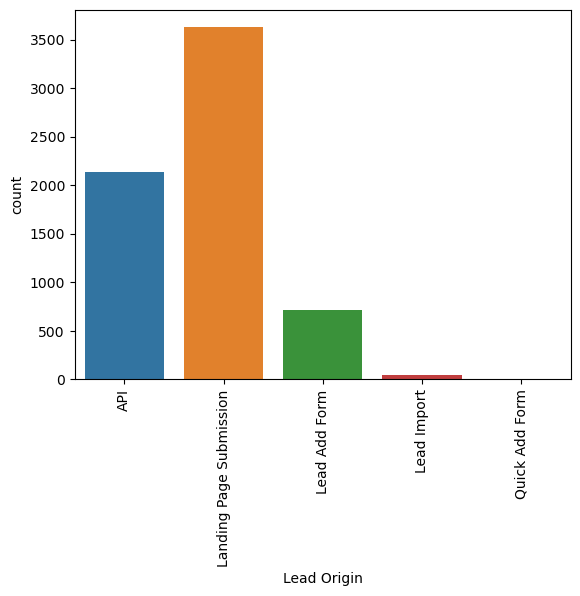

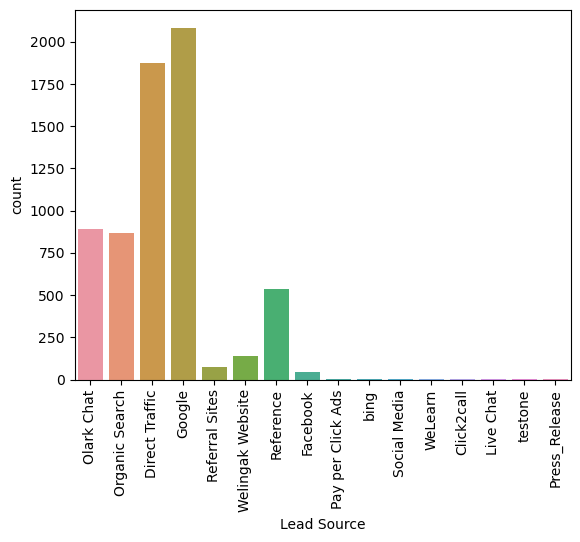

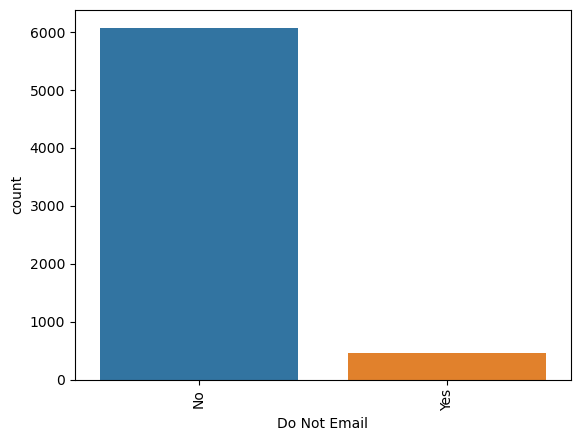

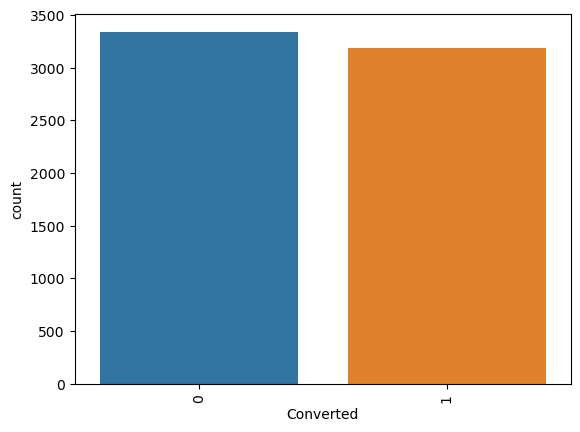

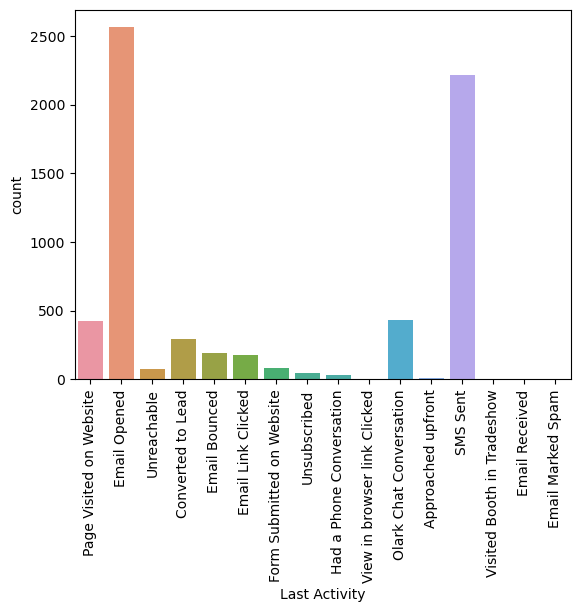

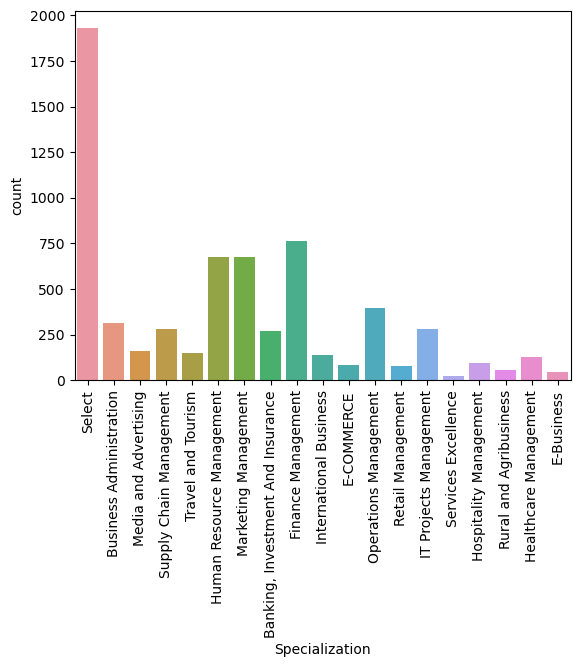

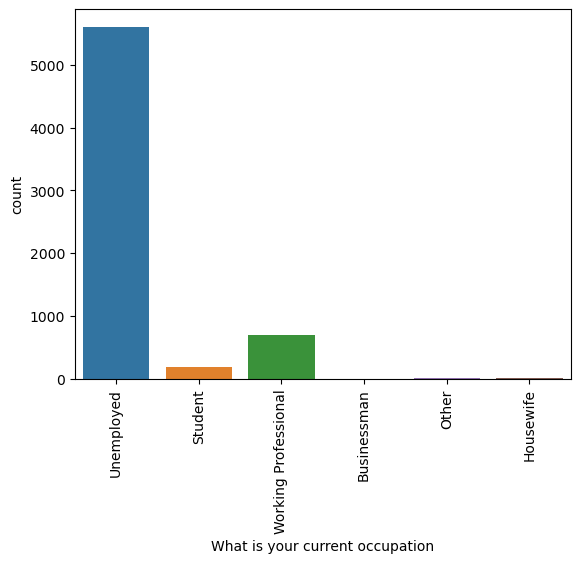

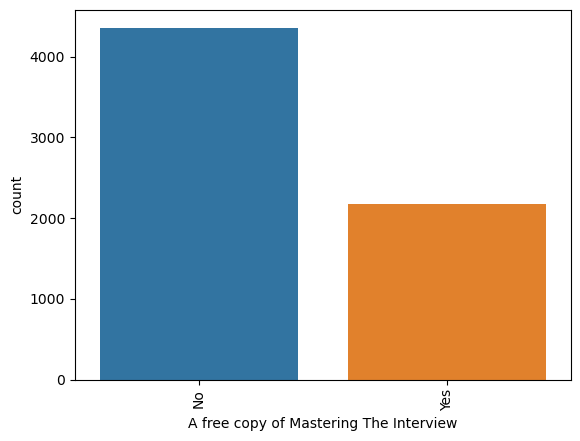

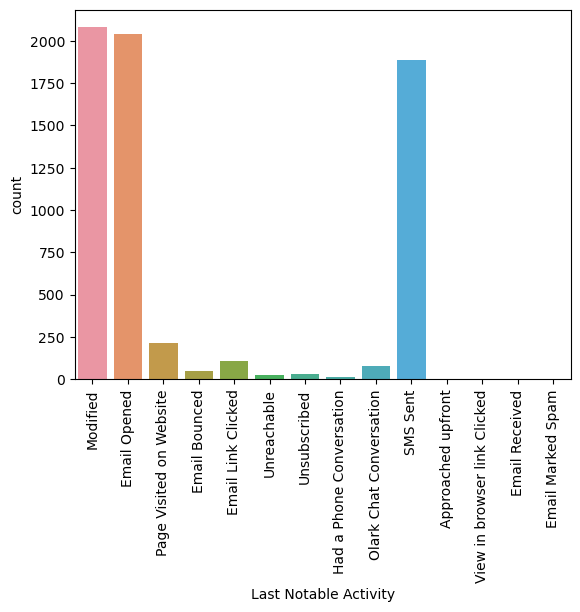

In [39]:
cols = ['Lead Origin', 'Lead Source', 'Do Not Email', 'Converted',
       'Last Activity', 'Specialization', 'What is your current occupation',
       'A free copy of Mastering The Interview', 'Last Notable Activity']

for col in cols:
    sns.countplot(x=col,data= lead_ds).tick_params(axis='x', rotation = 90)
    plt.xticks(rotation = 90)
    plt.show()







In [40]:

lead_ds.shape

(6532, 12)

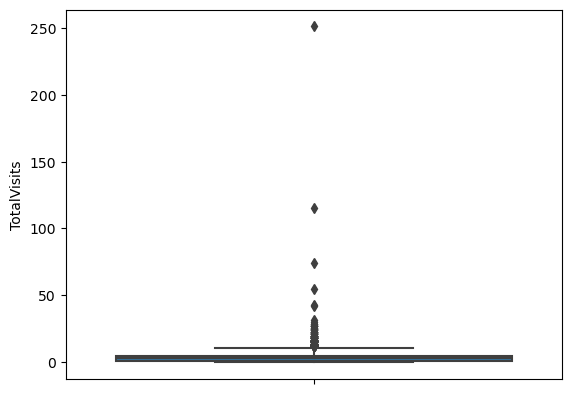

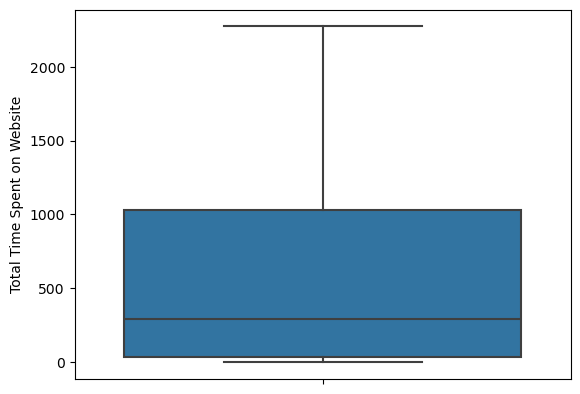

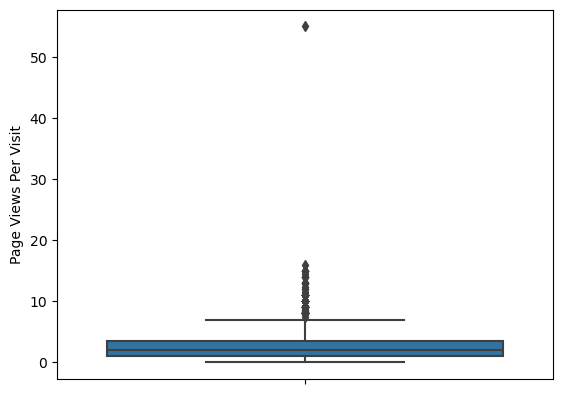

In [41]:
numerical_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

for col in numerical_cols:
    sns.boxplot(data = lead_ds, y = col)
    plt.show()


In [42]:
lead_ds.describe()

,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,6532.000000,6532.000000,6532.000000,6532.000000
mean,0.488518,3.595989,540.843693,2.460196
std,0.499906,4.993102,568.185493,2.147953
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,35.000000,1.000000
50%,0.000000,3.000000,293.000000,2.000000
75%,1.000000,5.000000,1031.250000,3.500000
max,1.000000,251.000000,2272.000000,55.000000


'TotalVisits' and 'Page Views Per Visit' both columns have one outlier each.

BIVARIATE ANALYSIS

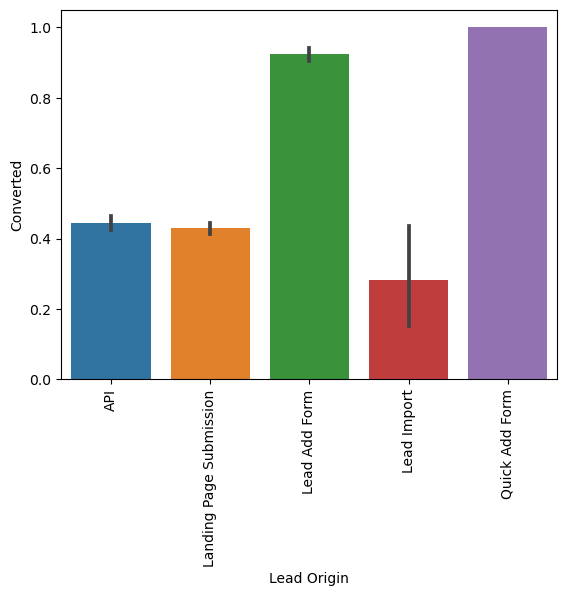

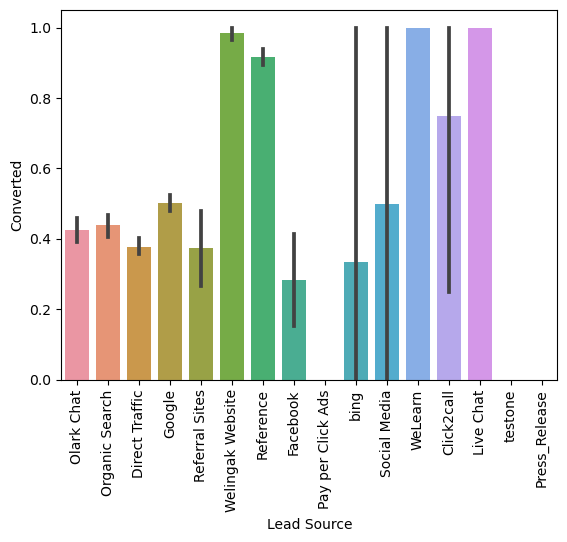

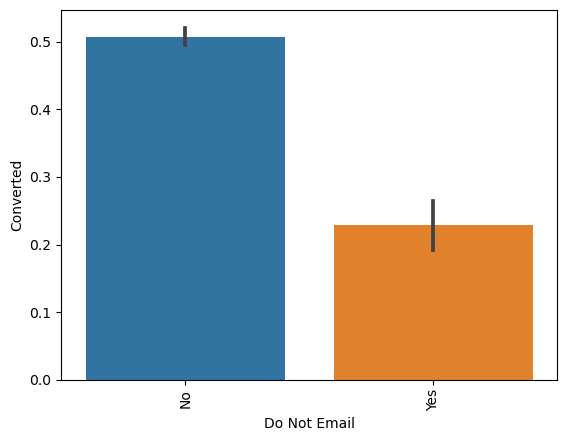

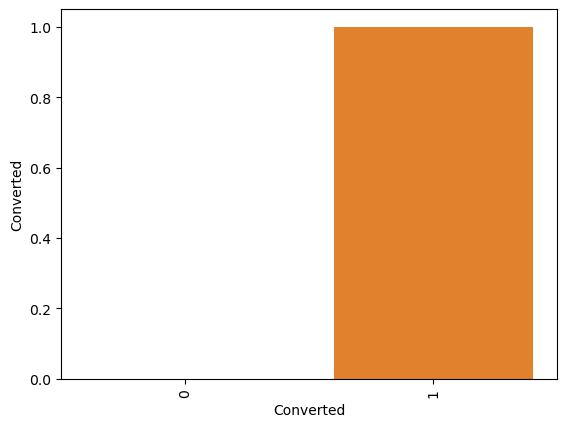

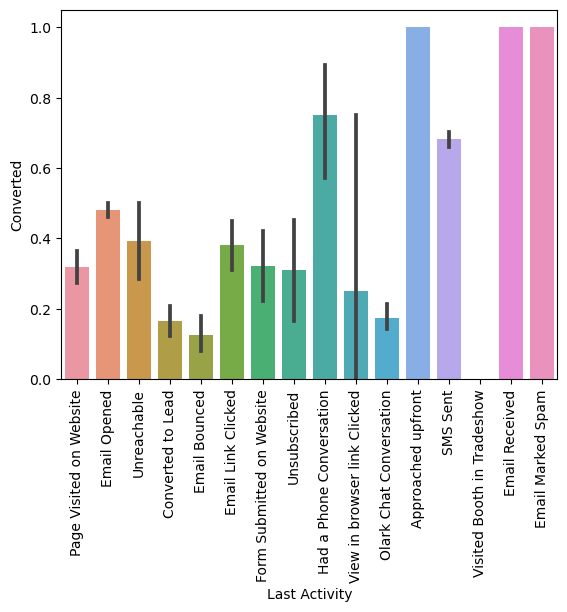

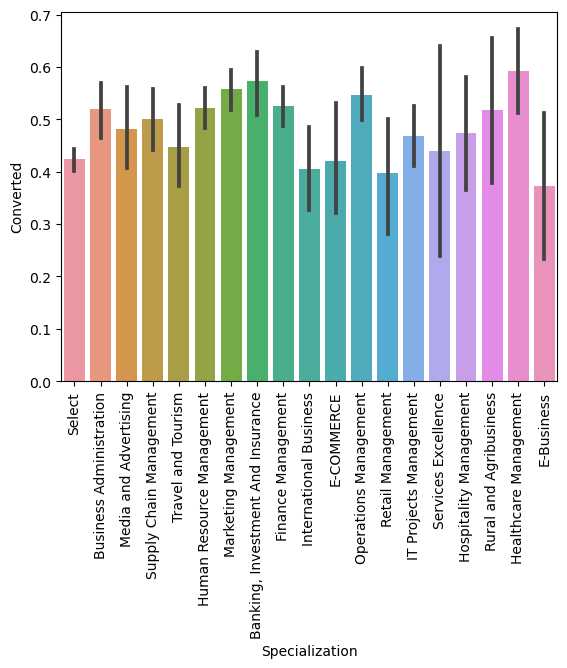

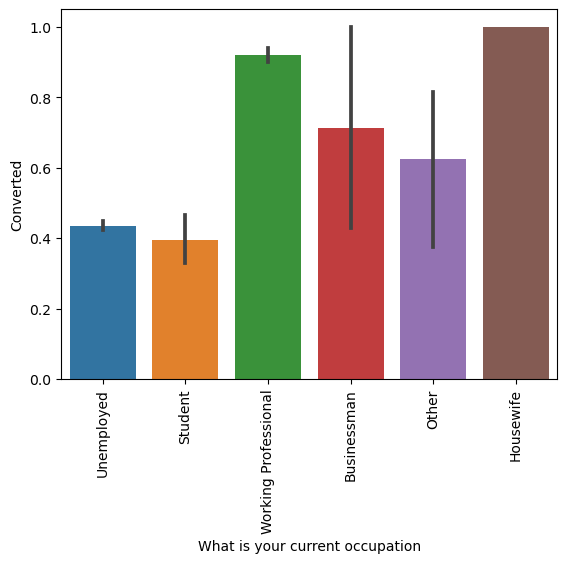

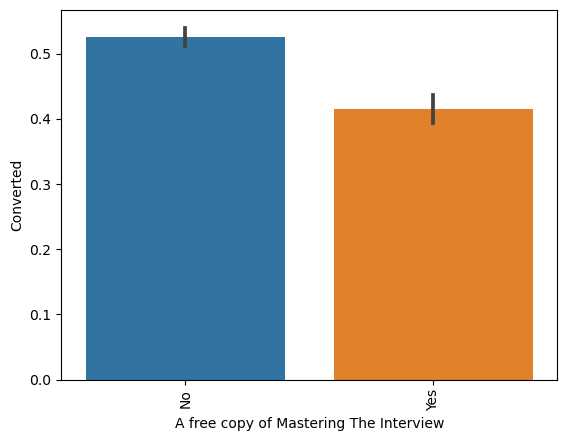

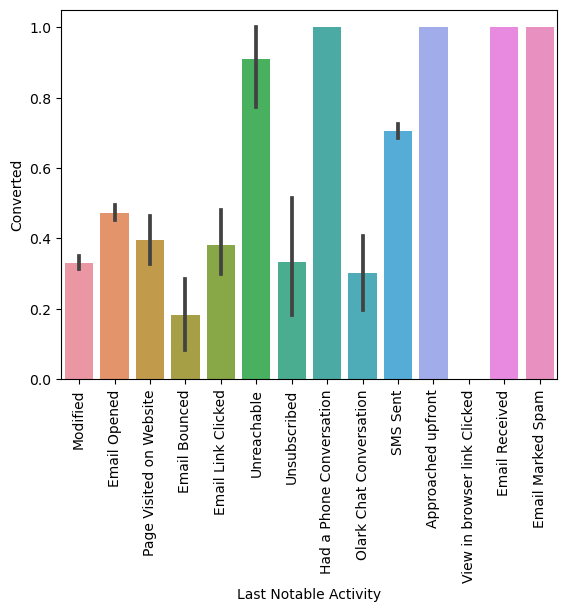

In [43]:
for col in cols:
    sns.barplot(data = lead_ds, x = col, y = 'Converted').tick_params(axis='x', rotation = 90)
    plt.show()

MULTIVARIATE ANALYSIS

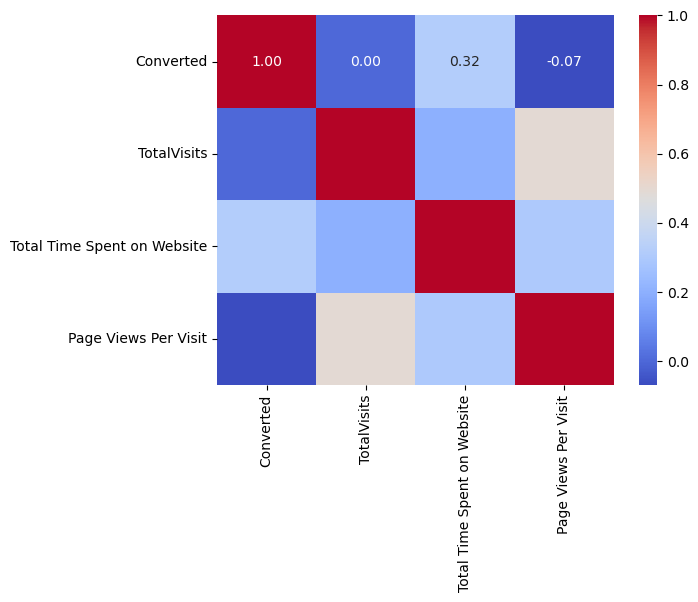

In [44]:
numeric_columns = lead_ds.select_dtypes(include=['number']).columns
correlation_matrix = lead_ds[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [45]:
# STEP 5 : DATA TRANSFORMATION
#Creating Dummy Variables
#Get list of categorical columns
cat_cols= lead_ds.select_dtypes(include=['object']).columns
cat_cols

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Last Activity',
       'Specialization', 'What is your current occupation',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [46]:
Specialization_dummy = pd.get_dummies(lead_ds['Specialization'], prefix = 'Specialization')
Specialization_dummy.head()

,"Specialization_Banking, Investment And Insurance",Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,Specialization_Human Resource Management,Specialization_IT Projects Management,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Select,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [47]:
# Drop 'Specialization_Select' category 

Specialization_dummy.drop('Specialization_Select', axis = 1, inplace = True)
Specialization_dummy.shape

(6532, 18)

In [48]:

Remaining = pd.get_dummies(lead_ds[['Lead Origin', 'Lead Source', 'Do Not Email',
       'Last Activity', 'What is your current occupation','A free copy of Mastering The Interview', 'Last Notable Activity']], drop_first = True)
Remaining.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Facebook,Lead Source_Google,Lead Source_Live Chat,Lead Source_Olark Chat,Lead Source_Organic Search,...,Last Notable Activity_Email Opened,Last Notable Activity_Email Received,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
2,True,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,True,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [49]:
lead_ds.drop(cat_cols, axis = 1, inplace = True)
lead_ds.shape

(6532, 4)

In [50]:
Specialization_dummy.head()

,"Specialization_Banking, Investment And Insurance",Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,Specialization_Human Resource Management,Specialization_IT Projects Management,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [51]:
# CONCAT ALL THE DATAFRAMES
lead_ds = pd.concat([lead_ds,Specialization_dummy], axis = 1)
lead_ds = pd.concat([lead_ds,Remaining], axis = 1)

In [52]:
lead_ds.shape

(6532, 76)

In [53]:
# TRAIN TEST SPLIT
# Import the train_test_split library
from sklearn.model_selection import train_test_split
X = lead_ds.drop('Converted', axis = 1)
y = lead_ds['Converted']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state = 100)

In [54]:
# SCALING
# Import MinMaxScaler library
from sklearn.preprocessing import MinMaxScaler
# SCALING THE NUMERICAL VARIABLES 
numerical_cols = ['TotalVisits', 'Total Time Spent on Website','Page Views Per Visit']
scaler = MinMaxScaler()

In [55]:
# Fit_transform the data inorder to Train the Data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_train.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,"Specialization_Banking, Investment And Insurance",Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,...,Last Notable Activity_Email Opened,Last Notable Activity_Email Received,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
8405,0.007968,0.066901,0.12500,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
6024,0.015936,0.084067,0.25000,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
148,0.019920,0.102113,0.15625,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3854,0.007968,0.232394,0.12500,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2784,0.063745,0.551496,0.20000,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [56]:
# CHECK CORRELATIONS
lead_ds.corr()

,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,"Specialization_Banking, Investment And Insurance",Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,...,Last Notable Activity_Email Opened,Last Notable Activity_Email Received,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
Converted,1.000000,0.001607,0.316880,-0.068889,0.034815,0.013752,-0.018960,-0.015415,0.026475,0.028916,...,-0.020186,0.012661,0.045694,-0.215707,-0.040348,-0.034581,0.275059,0.048911,-0.022122,-0.012093
TotalVisits,0.001607,1.000000,0.200101,0.490900,0.042849,0.035815,0.015687,0.019319,0.031890,0.026969,...,0.029501,0.005958,0.026318,-0.088702,-0.004373,0.227380,-0.029813,0.003116,-0.001154,0.010915
Total Time Spent on Website,0.316880,0.200101,1.000000,0.299313,0.026128,0.049192,0.003061,-0.001238,0.059473,0.020076,...,0.011701,0.004795,0.023768,-0.080416,-0.010740,0.032715,0.068198,0.009578,-0.003340,-0.009841
Page Views Per Visit,-0.068889,0.490900,0.299313,1.000000,0.075396,0.035503,0.037391,0.039660,0.062466,0.030688,...,0.053100,0.003110,0.015862,-0.077558,-0.041168,0.019175,0.029503,0.015730,0.023268,0.001209
"Specialization_Banking, Investment And Insurance",0.034815,0.042849,0.026128,0.075396,1.000000,-0.046572,-0.016871,-0.023223,-0.075314,-0.028948,...,0.008155,-0.002564,0.025319,-0.020934,-0.015301,-0.003348,0.024142,-0.012048,-0.014768,-0.002564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Last Notable Activity_Page Visited on Website,-0.034581,0.227380,0.032715,0.019175,-0.003348,0.019184,0.006372,0.002794,0.011149,-0.019353,...,-0.123814,-0.002272,-0.008199,-0.125493,-0.019920,1.000000,-0.117107,-0.010673,-0.013083,-0.002272
Last Notable Activity_SMS Sent,0.275059,-0.029813,0.068198,0.029503,0.024142,0.019248,-0.026870,0.004807,0.005928,0.009491,...,-0.430151,-0.007893,-0.028484,-0.435984,-0.069206,-0.117107,1.000000,-0.037080,-0.045452,-0.007893
Last Notable Activity_Unreachable,0.048911,0.003116,0.009578,0.015730,-0.012048,-0.013064,-0.004732,0.017363,0.052958,0.011167,...,-0.039204,-0.000719,-0.002596,-0.039735,-0.006307,-0.010673,-0.037080,1.000000,-0.004142,-0.000719
Last Notable Activity_Unsubscribed,-0.022122,-0.001154,-0.003340,0.023268,-0.014768,0.004176,0.020901,-0.007985,0.001011,0.037330,...,-0.048055,-0.000882,-0.003182,-0.048707,-0.007731,-0.013083,-0.045452,-0.004142,1.000000,-0.000882


In [57]:
# STEP 6: MODEL BUILDING
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()


In [58]:
# Select top 15 features
from sklearn.feature_selection import RFE
rfe = RFE(estimator = LR ,n_features_to_select = 15 )
rfe = rfe.fit(X_train, y_train)

In [59]:
# Let's see what are the features selected by RFE
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('TotalVisits', True, 1),
 ('Total Time Spent on Website', True, 1),
 ('Page Views Per Visit', False, 2),
 ('Specialization_Banking, Investment And Insurance', False, 12),
 ('Specialization_Business Administration', False, 24),
 ('Specialization_E-Business', False, 23),
 ('Specialization_E-COMMERCE', False, 18),
 ('Specialization_Finance Management', False, 17),
 ('Specialization_Healthcare Management', False, 27),
 ('Specialization_Hospitality Management', False, 53),
 ('Specialization_Human Resource Management', False, 25),
 ('Specialization_IT Projects Management', False, 15),
 ('Specialization_International Business', False, 16),
 ('Specialization_Marketing Management', False, 20),
 ('Specialization_Media and Advertising', False, 26),
 ('Specialization_Operations Management', False, 22),
 ('Specialization_Retail Management', False, 46),
 ('Specialization_Rural and Agribusiness', False, 13),
 ('Specialization_Services Excellence', False, 28),
 ('Specialization_Supply Chain Manageme

In [60]:
col_train = X_train.columns[rfe.support_]

In [61]:
len(X_train.columns[rfe.support_])
col_train

Index(['TotalVisits', 'Total Time Spent on Website',
       'Lead Origin_Lead Add Form', 'Lead Source_Olark Chat',
       'Lead Source_Welingak Website', 'Do Not Email_Yes',
       'Last Activity_Email Bounced', 'Last Activity_Olark Chat Conversation',
       'Last Activity_SMS Sent', 'What is your current occupation_Student',
       'What is your current occupation_Unemployed',
       'What is your current occupation_Working Professional',
       'Last Notable Activity_Had a Phone Conversation',
       'Last Notable Activity_Modified', 'Last Notable Activity_Unreachable'],
      dtype='object')

In [62]:
X_train = X_train[col_train]

Analyse the p-value and VIF for multicollinearity check.

In [63]:
# Import variance_inflation_factor library
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [64]:
# Add a constant to X_train dataset and fit the logistic regression model
def buildmodel(X):
    X_sm = sm.add_constant(X)
    log_X = sm.GLM(y_train, X_sm, family = sm.families.Binomial())     
    res = log_X.fit()
    print(res.summary())
    return res

# A common VIF dataframe for all the variables 
def show_vif(X):
    vif = pd.DataFrame()
    vif['Features'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    print(vif)

In [65]:
# FIRST MODEL 
np.asarray(X_train)
X_train= X_train.astype(float)
buildmodel(X_train)
show_vif(X_train)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 4572
Model:                            GLM   Df Residuals:                     4556
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2077.6
Date:                Fri, 10 Jan 2025   Deviance:                       4155.2
Time:                        14:33:04   Pearson chi2:                 4.86e+03
No. Iterations:                    21   Pseudo R-squ. (CS):             0.3793
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

It is clear that p-value is very high for column 'Last Notable Activity_Had a Phone Conversation' so drop this column.

In [66]:
X_train.drop('Last Notable Activity_Had a Phone Conversation', axis = 1, inplace = True)

In [67]:
# SECOND MODEL
buildmodel(X_train)
show_vif(X_train)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 4572
Model:                            GLM   Df Residuals:                     4557
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2085.3
Date:                Fri, 10 Jan 2025   Deviance:                       4170.5
Time:                        14:33:04   Pearson chi2:                 4.86e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3772
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

From the above table it is clear that 'What is your current occupation_Student' and 'What is your current occupation_Unemployed' both columns have p value > 0.05 and high vif value.Drop the column 'What is your current occupation_Unemployed'.

In [68]:
X_train.drop('What is your current occupation_Unemployed', axis = 1, inplace = True)

In [69]:
# THIRD MODEL
buildmodel(X_train)
show_vif(X_train)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 4572
Model:                            GLM   Df Residuals:                     4558
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2086.3
Date:                Fri, 10 Jan 2025   Deviance:                       4172.7
Time:                        14:33:04   Pearson chi2:                 4.87e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3769
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

Once again when we check the column 'What is your current occupation_Student' has Vif value > 0.05, so drop the column. 

In [70]:
X_train.drop('What is your current occupation_Student', axis = 1, inplace = True)

In [71]:
# FOURTH MODEL
buildmodel(X_train)
show_vif(X_train)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 4572
Model:                            GLM   Df Residuals:                     4559
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2086.3
Date:                Fri, 10 Jan 2025   Deviance:                       4172.7
Time:                        14:33:04   Pearson chi2:                 4.87e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3769
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

Looking at the table, the p value of all the variables is <0.05 and Vif is below 5 . So let's go ahead with Fourth Model.

In [72]:
X_train.corr()

,TotalVisits,Total Time Spent on Website,Lead Origin_Lead Add Form,Lead Source_Olark Chat,Lead Source_Welingak Website,Do Not Email_Yes,Last Activity_Email Bounced,Last Activity_Olark Chat Conversation,Last Activity_SMS Sent,What is your current occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_Unreachable
TotalVisits,1.000000,0.180938,-0.185444,-0.222258,-0.085647,0.032773,-0.041001,-0.067684,-0.041287,-0.016618,-0.089330,0.009991
Total Time Spent on Website,0.180938,1.000000,-0.195045,-0.317890,-0.103031,-0.049448,-0.026058,-0.112587,0.052586,0.074882,-0.080048,0.010333
Lead Origin_Lead Add Form,-0.185444,-0.195045,1.000000,-0.134988,0.426056,-0.019441,-0.021059,-0.085549,0.102775,0.193745,0.032835,-0.011045
Lead Source_Olark Chat,-0.222258,-0.317890,-0.134988,1.000000,-0.059253,-0.039471,-0.011547,0.286468,-0.061347,-0.063253,0.038568,-0.014549
Lead Source_Welingak Website,-0.085647,-0.103031,0.426056,-0.059253,1.000000,0.005842,-0.016212,-0.032763,0.066648,-0.052962,-0.013847,-0.009449
Do Not Email_Yes,0.032773,-0.049448,-0.019441,-0.039471,0.005842,1.000000,0.558910,-0.038690,0.000010,-0.057724,0.063658,-0.017160
Last Activity_Email Bounced,-0.041001,-0.026058,-0.021059,-0.011547,-0.016212,0.558910,1.000000,-0.043568,-0.121861,-0.055059,0.156511,-0.010584
Last Activity_Olark Chat Conversation,-0.067684,-0.112587,-0.085549,0.286468,-0.032763,-0.038690,-0.043568,1.000000,-0.187340,-0.065305,0.284309,-0.016271
Last Activity_SMS Sent,-0.041287,0.052586,0.102775,-0.061347,0.066648,0.000010,-0.121861,-0.187340,1.000000,0.112184,-0.278694,-0.045510
What is your current occupation_Working Professional,-0.016618,0.074882,0.193745,-0.063253,-0.052962,-0.057724,-0.055059,-0.065305,0.112184,1.000000,-0.069853,0.022417


In [73]:
# STEP 6: EVALUATING THE MODELS
res = buildmodel(X_train)
show_vif(X_train)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 4572
Model:                            GLM   Df Residuals:                     4559
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2086.3
Date:                Fri, 10 Jan 2025   Deviance:                       4172.7
Time:                        14:33:05   Pearson chi2:                 4.87e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3769
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [74]:
# Add a  constant to linear logistic model
X_train_sm = sm.add_constant(X_train)

# Find probability of 'converted' variable, predict the target variable
y_train_pred = res.predict(sm.add_constant(X_train_sm))

In [75]:
y_train_pred

8405    0.013434
6024    0.187636
148     0.203456
3854    0.534813
2784    0.697771
          ...   
8541    0.969833
96      0.165416
5730    0.164976
8453    0.120263
8035    0.649404
Length: 4572, dtype: float64

In [76]:
# Reshape 'y_train_pred' into an array

y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred[:10]

array([0.01343399, 0.18763576, 0.20345553, 0.53481286, 0.69777069,
       0.36763275, 0.72979017, 0.90485625, 0.07840419, 0.69597062])

In [77]:
# Creating dataframe with two columns - Actual and predicted conversion columns
y_train_pred_df = pd.DataFrame({'Actual_converted': y_train.values, 'Prob_converted': y_train_pred})

In [78]:
y_train_pred_df.head()

,Actual_converted,Prob_converted
0,0,0.013434
1,0,0.187636
2,0,0.203456
3,1,0.534813
4,1,0.697771


In [79]:
# Set the cut-off probability of converted as 0.4
y_train_pred_df['Predicted'] = y_train_pred_df.Prob_converted.map(lambda x: 1 if x > 0.4 else 0)

In [80]:
y_train_pred_df.head()

,Actual_converted,Prob_converted,Predicted
0,0,0.013434,0
1,0,0.187636,0
2,0,0.203456,0
3,1,0.534813,1
4,1,0.697771,1


In [81]:
# Evaluate the model with metrics like Accuracy, Sensitivity, and Specificity
from sklearn import metrics
confusion = metrics.confusion_matrix(y_train_pred_df.Actual_converted, y_train_pred_df.Predicted)

In [82]:
confusion

array([[1702,  641],
       [ 343, 1886]], dtype=int64)

In [83]:
# Confusion Matrix

confusion_matrix_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion, display_labels = [0, 1])

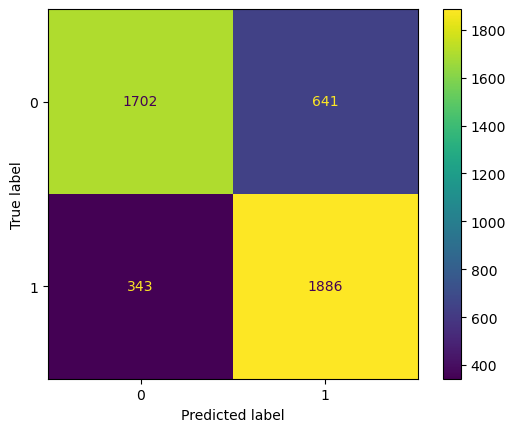

In [84]:
confusion_matrix_display.plot()
plt.show()

The Confusion Matrix created has four different quadrants:
True Positive (Bottom-Right Quadrant) -> converted are correctly predicted(Accurate Prediction)

True Negative (Top-Left Quadrant) -> Not converted are correctly predicted(Wrong Prediction)

False Positive (Top-Right Quadrant) -> Not converted are falsely predicted as converted(Accurate Prediction)

False Negative (Bottom-Left Quadrant) -> converted are falsely predicted as not converted(Wrong Prediction)

In [85]:
# Accuracy score

print(metrics.accuracy_score(y_train_pred_df.Actual_converted, y_train_pred_df.Predicted))

0.7847769028871391


In [86]:
TN = confusion[0,0]
FP = confusion[0,1]
FN = confusion[1,0]
TP = confusion[1,1]

In [87]:
y_train.shape

(4572,)

In [88]:
# Accuracy

acc = (TN + TP)/(y_train.shape[0])

In [89]:
acc

0.7847769028871391

In [90]:
# Sensitivity

sen = TP / (TP+FN)
sen

0.8461193360251233

In [91]:
# Specificity

spec =  TN / (TN+FP)
spec

0.726419120785318

In [92]:
#FINDING THE OPTIMAL CUTOFF
# ROC function
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None


In [93]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_df.Actual_converted, y_train_pred_df.Prob_converted, drop_intermediate = False )

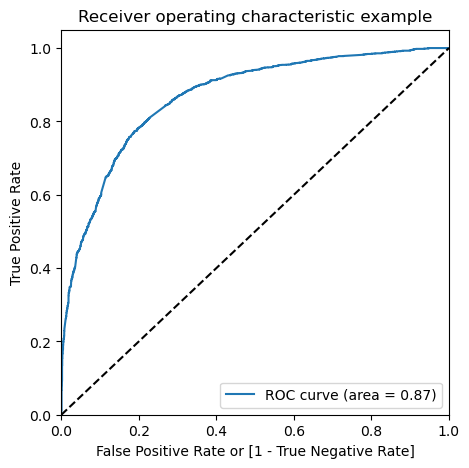

In [94]:
# Call the ROC function

draw_roc(y_train_pred_df.Actual_converted, y_train_pred_df.Prob_converted)

The area covered by the ROC curve is 0.87 (87%) which is perfectly good to continue.

In [95]:
# Find the optimal cutoff by plotting a graph for different probability cutoffs
for i in np.arange(0.1,1,0.1):
    i = round(i,1)
    y_train_pred_df[i] = y_train_pred_df.Prob_converted.map(lambda x: 1 if x > i else 0)
    
y_train_pred_df.head()


,Actual_converted,Prob_converted,Predicted,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,0.013434,0,0,0,0,0,0,0,0,0,0
1,0,0.187636,0,1,0,0,0,0,0,0,0,0
2,0,0.203456,0,1,1,0,0,0,0,0,0,0
3,1,0.534813,1,1,1,1,1,1,0,0,0,0
4,1,0.697771,1,1,1,1,1,1,1,0,0,0


In [96]:
Prob_cutoff_df = pd.DataFrame( columns = ['probability','accuracy','sensitivity','specificity'])

num = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    confusion_mat = metrics.confusion_matrix(y_train_pred_df.Actual_converted, y_train_pred_df[i] )
    
    accuracy = (confusion_mat[0,0]+confusion_mat[1,1])/y_train_pred_df.shape[0]
    
    specificity = confusion_mat[0,0]/(confusion_mat[0,0]+confusion_mat[0,1])
    sensitivity = confusion_mat[1,1]/(confusion_mat[1,0]+confusion_mat[1,1])
    Prob_cutoff_df.loc[i] =[ i , accuracy, sensitivity, specificity]
    
Prob_cutoff_df

,probability,accuracy,sensitivity,specificity
0.1,0.1,0.569335,0.985644,0.173282
0.2,0.2,0.707130,0.943921,0.481861
0.3,0.3,0.763998,0.900852,0.633803
0.4,0.4,0.784777,0.846119,0.726419
0.5,0.5,0.789589,0.744729,0.832266
0.6,0.6,0.774934,0.675639,0.869398
0.7,0.7,0.738408,0.555406,0.912505
0.8,0.8,0.711286,0.458502,0.951771
0.9,0.9,0.648950,0.297891,0.982928


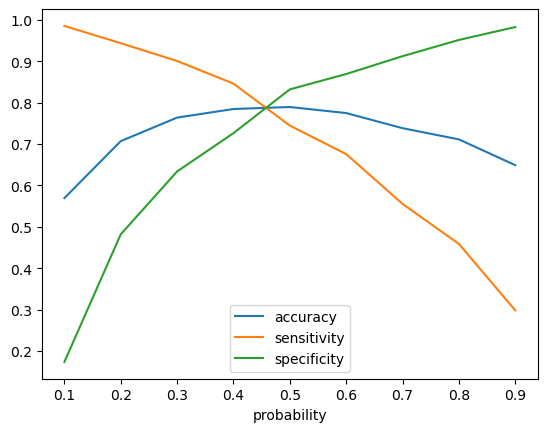

In [97]:
Prob_cutoff_df.plot.line(x='probability', y=['accuracy','sensitivity','specificity'])
plt.show()

The optimal cutoff probability is 0.44 as the metrics accuracy, sensitivity and specificity all meet at probability 0.44.

In [98]:
y_train_pred_df['final_predicted'] = y_train_pred_df.Prob_converted.map(lambda x: 1 if x > 0.44 else 0)
y_train_pred_df.head(5)

,Actual_converted,Prob_converted,Predicted,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_predicted
0,0,0.013434,0,0,0,0,0,0,0,0,0,0,0
1,0,0.187636,0,1,0,0,0,0,0,0,0,0,0
2,0,0.203456,0,1,1,0,0,0,0,0,0,0,0
3,1,0.534813,1,1,1,1,1,1,0,0,0,0,1
4,1,0.697771,1,1,1,1,1,1,1,0,0,0,1


In [99]:
# Finding the Train accuracy
acc_train = metrics.accuracy_score(y_train_pred_df.Actual_converted, y_train_pred_df.final_predicted) 
acc_train

0.7906824146981627

In [100]:
# The Confusion Matrix
confusion_train = metrics.confusion_matrix(y_train_pred_df.Actual_converted, y_train_pred_df.final_predicted)
confusion_train

array([[1861,  482],
       [ 475, 1754]], dtype=int64)

In [101]:
TN = confusion_train[0,0]
FP = confusion_train[0,1]
FN = confusion_train[1,0]
TP = confusion_train[1,1]

In [102]:
# Train Sensitivity
sensitivity_train = TP / (TP + FN)
sensitivity_train

0.7868999551368326

In [103]:
# Train Specificity
specificity_train = TN / (TN + FP)
specificity_train

0.7942808365343577

In [104]:
# Train False Positive Rate (FPR)
FPR_train = FP / (TN + FN)
FPR_train

0.20633561643835616

 Overall the Model is good with Sensitivity = 0.78 (High), Specificity = 0.79 and FPR = 0.20 (Low) 

In [105]:
# STEP 8: PREDICTIONS ON THE TEST DATASET
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_test = X_test[X_train.columns]
X_test.head(3)

,TotalVisits,Total Time Spent on Website,Lead Origin_Lead Add Form,Lead Source_Olark Chat,Lead Source_Welingak Website,Do Not Email_Yes,Last Activity_Email Bounced,Last Activity_Olark Chat Conversation,Last Activity_SMS Sent,What is your current occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_Unreachable
2185,0.011952,0.116197,False,False,False,False,False,False,False,False,False,False
2037,0.007968,0.151408,False,False,False,False,False,True,False,False,True,False
9025,0.011952,0.055458,False,False,False,False,False,False,True,False,False,False


In [106]:
X_test_sm = sm.add_constant(X_test)
X_test_sm.head(3)

,const,TotalVisits,Total Time Spent on Website,Lead Origin_Lead Add Form,Lead Source_Olark Chat,Lead Source_Welingak Website,Do Not Email_Yes,Last Activity_Email Bounced,Last Activity_Olark Chat Conversation,Last Activity_SMS Sent,What is your current occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_Unreachable
2185,1.0,0.011952,0.116197,False,False,False,False,False,False,False,False,False,False
2037,1.0,0.007968,0.151408,False,False,False,False,False,True,False,False,True,False
9025,1.0,0.011952,0.055458,False,False,False,False,False,False,True,False,False,False


In [107]:
y_test_pred = res.predict(X_test_sm.astype(float)) 


In [108]:
y_test_pred_df = pd.DataFrame({'Actual_converted': y_test.values, 'Prob_converted': y_test_pred})
y_test_pred_df.head(3)

,Actual_converted,Prob_converted
2185,0,0.206346
2037,0,0.056237
9025,0,0.351877


In [109]:
# Using 0.44 as the cutoff to make predictions

y_test_pred_df['final_predicted'] = y_test_pred_df.Prob_converted.map(lambda x: 1 if x > 0.44 else 0)
y_test_pred_df.head(3)

,Actual_converted,Prob_converted,final_predicted
2185,0,0.206346,0
2037,0,0.056237,0
9025,0,0.351877,0


In [110]:
# Accuracy Score of Test Dataset

acc_test = metrics.accuracy_score(y_test_pred_df.Actual_converted, y_test_pred_df.final_predicted) 
acc_test

0.7974489795918367

In [111]:
# Confusion Metrix of Test Dataset

confusion_test = metrics.confusion_matrix(y_test_pred_df.Actual_converted, y_test_pred_df.final_predicted)
confusion_test

array([[810, 188],
       [209, 753]], dtype=int64)

In [112]:
TN_test = confusion_test[0,0]
FP_test = confusion_test[0,1]
FN_test = confusion_test[1,0]
TP_test = confusion_test[1,1]

In [113]:
# Sensitivity of Test Dataset

sensitivity_test = TP_test / (TP_test + FN_test)
sensitivity_test

0.7827442827442828

In [114]:
# Specificity of Test Dataset

specificity_test = TN_test / (TN_test + FP_test)
specificity_test

0.811623246492986

In [115]:
result_metrics = pd.DataFrame({'DataSet_type': ['Train', 'Test'], 
                               'Accuracy': [acc_train, acc_test],
                               'Sensitivity': [sensitivity_train, sensitivity_test], 
                               'Specificity': [specificity_train, specificity_test]
                              })
result_metrics 

,DataSet_type,Accuracy,Sensitivity,Specificity
0,Train,0.790682,0.786900,0.794281
1,Test,0.797449,0.782744,0.811623


In [116]:
#PRECISION-RECALL VIEW
# Train dataset
precision = metrics.precision_score(y_train_pred_df.Actual_converted, y_train_pred_df.Predicted)
precision

0.7463395330431342

In [117]:
# Sensitivity
sensitivity_recall = metrics.recall_score(y_train_pred_df.Actual_converted, y_train_pred_df.Predicted)
sensitivity_recall

0.8461193360251233

In [118]:
from sklearn.metrics import precision_recall_curve
p, r, thresholds = precision_recall_curve(y_train_pred_df.Actual_converted, y_train_pred_df.Prob_converted)



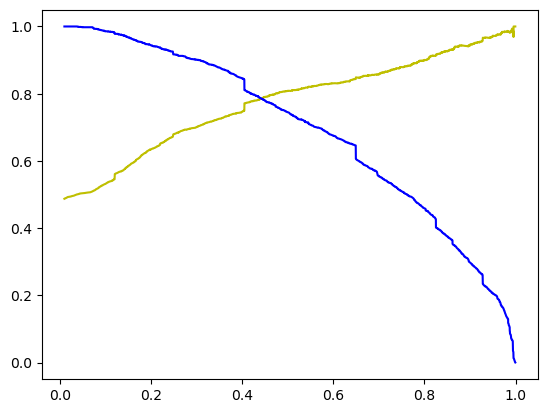

In [119]:
plt.plot(thresholds, p[:-1], "y-")
plt.plot(thresholds, r[:-1], "b-")
plt.show()

In [120]:
#The optimal probability cutoff is approximately 0.44
y_train_pred_df['final_predicted'] = y_train_pred_df.Prob_converted.map(lambda x: 1 if x > 0.44 else 0)

y_train_pred_df.head()

,Actual_converted,Prob_converted,Predicted,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_predicted
0,0,0.013434,0,0,0,0,0,0,0,0,0,0,0
1,0,0.187636,0,1,0,0,0,0,0,0,0,0,0
2,0,0.203456,0,1,1,0,0,0,0,0,0,0,0
3,1,0.534813,1,1,1,1,1,1,0,0,0,0,1
4,1,0.697771,1,1,1,1,1,1,1,0,0,0,1


In [121]:
result_metrics = pd.DataFrame({'DataSet_type': ['Train', 'Test'], 
                               'Accuracy': [acc_train, acc_test],
                               'Sensitivity': [sensitivity_train, sensitivity_test], 
                               'Specificity': [specificity_train, specificity_test]
                              })
result_metrics 

,DataSet_type,Accuracy,Sensitivity,Specificity
0,Train,0.790682,0.786900,0.794281
1,Test,0.797449,0.782744,0.811623


In [122]:
#F-Score
F = (2 * precision * sensitivity_recall)/(precision + sensitivity_recall)
F

0.7931034482758621

F - Score is 0.79 which mean the Machine Learning Model is good.

In [123]:
# Conclusion
buildmodel(X_train)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 4572
Model:                            GLM   Df Residuals:                     4559
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2086.3
Date:                Fri, 10 Jan 2025   Deviance:                       4172.7
Time:                        14:33:06   Pearson chi2:                 4.87e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3769
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

                                                    Conclusion
In oder to increase the conversion rate the CEO of the company should focus mostly on the columns listed below:-   
TotalVisits                                              
Total Time Spent on Website                          
Lead Origin_Lead Add Form                                
Lead Source_Olark Chat                                   
Lead Source_Welingak Website  
What is your current occupation_Working Professional   

The leads are most likely to get converted depending on Total Visits and Total Time spent by the lead on the Website.                                             